<a href="https://colab.research.google.com/github/mysciz/xjtu-ml-class/blob/main/exp/code/exp4/ml-exp4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 实验4：聚类算法实现与对比

本实验分别对二维点数据、时序数据和UCI数据集使用3种聚类算法完成聚类任务，对比聚类结果。

## 实验内容
1. 手工实现 KMeans 算法
2. 手工实现 SLINK（单链接层次聚类）算法
3. 手工实现 DBSCAN 算法
4. 使用 sklearn 库实现三种算法对比
5. 对比聚类结果、运行时间、内存占用
6. 调整算法参数观察影响

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import tracemalloc
from collections import defaultdict
from sklearn.cluster import KMeans as SklearnKMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

## 1. 手工实现 KMeans 算法

In [2]:
class MyKMeans:
    """手工实现 KMeans 聚类算法"""

    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels = None
        self.inertia_ = None

    def fit(self, X):
        """拟合数据"""
        n_samples, n_features = X.shape

        # 初始化随机种子
        if self.random_state is not None:
            np.random.seed(self.random_state)

        # 随机初始化质心
        idx = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[idx].copy()

        for iteration in range(self.max_iter):
            # 分配步骤：将每个点分配到最近的质心
            distances = self._compute_distances(X)
            self.labels = np.argmin(distances, axis=1)

            # 更新步骤：重新计算质心
            new_centroids = np.zeros((self.n_clusters, n_features))
            for k in range(self.n_clusters):
                cluster_points = X[self.labels == k]
                if len(cluster_points) > 0:
                    new_centroids[k] = np.mean(cluster_points, axis=0)
                else:
                    # 处理空簇：重新随机初始化
                    new_centroids[k] = X[np.random.randint(n_samples)]

            # 检查收敛
            centroid_shift = np.sum((new_centroids - self.centroids) ** 2)
            self.centroids = new_centroids

            if centroid_shift < self.tol:
                break

        # 计算惯性（簇内平方和）
        self.inertia_ = self._compute_inertia(X)
        return self

    def _compute_distances(self, X):
        """计算每个点到每个质心的欧氏距离"""
        # 使用广播计算距离
        distances = np.sqrt(
            np.sum((X[:, np.newaxis, :] - self.centroids[np.newaxis, :, :]) ** 2, axis=2)
        )
        return distances

    def _compute_inertia(self, X):
        """计算簇内平方和"""
        inertia = 0.0
        for k in range(self.n_clusters):
            cluster_points = X[self.labels == k]
            if len(cluster_points) > 0:
                inertia += np.sum((cluster_points - self.centroids[k]) ** 2)
        return inertia

    def predict(self, X):
        """预测新数据点的簇标签"""
        distances = self._compute_distances(X)
        return np.argmin(distances, axis=1)

    def fit_predict(self, X):
        """拟合并预测"""
        self.fit(X)
        return self.labels

## 2. 手工实现 SLINK（单链接层次聚类）算法

In [3]:
class MySLINK:
    """
    手工实现 SLINK（单链接层次聚类）算法
    使用经典 SLINK 算法（Sibson, 1973），时间复杂度 O(n^2)
    """

    def __init__(self, n_clusters=3):
        self.n_clusters = n_clusters
        self.labels = None
        self.linkage_matrix = None

    def fit(self, X):
        """
        使用 SLINK 算法进行单链接聚类
        """
        n = X.shape[0]

        # 初始化 SLINK 数组
        pi = np.arange(n)  # 父节点指针
        lambda_ = np.full(n, np.inf)  # 到父节点的距离
        mu = np.full(n, np.inf)  # 临时距离数组

        # SLINK 算法核心：逐个添加点
        for i in range(1, n):
            # 计算点 i 到之前所有点的距离
            for j in range(i):
                mu[j] = np.linalg.norm(X[i] - X[j])

            # 更新指针结构
            for j in range(i):
                if lambda_[j] >= mu[j]:
                    mu[pi[j]] = min(mu[pi[j]], lambda_[j])
                    lambda_[j] = mu[j]
                    pi[j] = i
                else:
                    mu[pi[j]] = min(mu[pi[j]], mu[j])

            # 确保局部最优性
            for j in range(i):
                if lambda_[j] >= lambda_[pi[j]]:
                    pi[j] = i

        # 根据 n_clusters 切断树状图得到聚类结果
        self.labels = self._cut_tree(pi, lambda_, n)

        return self

    def _cut_tree(self, pi, lambda_, n):
        """根据 n_clusters 切断树得到聚类标签"""
        if n <= self.n_clusters:
            return np.arange(n)

        # 收集所有边 (距离, 点i, 点j)
        edges = []
        for i in range(n):
            if pi[i] != i and lambda_[i] < np.inf:
                edges.append((lambda_[i], i, pi[i]))

        # 按距离排序
        edges.sort()

        # 使用并查集合并
        parent = list(range(n))

        def find(x):
            if parent[x] != x:
                parent[x] = find(parent[x])
            return parent[x]

        def union(x, y):
            px, py = find(x), find(y)
            if px != py:
                parent[px] = py

        num_clusters = n

        for dist, i, j in edges:
            pi_i, pi_j = find(i), find(j)
            if pi_i != pi_j:
                union(i, j)
                num_clusters -= 1
                if num_clusters == self.n_clusters:
                    break

        # 分配簇标签
        labels = np.zeros(n, dtype=int)
        cluster_map = {}
        current_label = 0

        for i in range(n):
            root = find(i)
            if root not in cluster_map:
                cluster_map[root] = current_label
                current_label += 1
            labels[i] = cluster_map[root]

        return labels

    def fit_predict(self, X):
        self.fit(X)
        return self.labels

## 3. 手工实现 DBSCAN 算法

In [4]:
class MyDBSCAN:
    """手工实现 DBSCAN 聚类算法"""

    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples
        self.labels = None

    def fit(self, X):
        """拟合数据"""
        n_samples = X.shape[0]
        self.labels = np.full(n_samples, -1, dtype=int)  # -1 表示噪声点

        # 构建邻域图
        neighbors = self._region_query(X)

        cluster_id = 0
        visited = np.zeros(n_samples, dtype=bool)

        for i in range(n_samples):
            if visited[i]:
                continue

            visited[i] = True

            if len(neighbors[i]) >= self.min_samples:
                # i 是核心点，开始扩展簇
                self._expand_cluster(X, i, neighbors, cluster_id, visited)
                cluster_id += 1

        return self

    def _region_query(self, X):
        """
        为每个点找到 eps 邻域内的所有点
        返回邻域列表
        """
        n_samples = X.shape[0]
        neighbors = [[] for _ in range(n_samples)]

        for i in range(n_samples):
            # 计算点 i 到所有其他点的距离
            dists = np.sqrt(np.sum((X - X[i]) ** 2, axis=1))
            neighbors[i] = np.where(dists <= self.eps)[0].tolist()

        return neighbors

    def _expand_cluster(self, X, core_idx, neighbors, cluster_id, visited):
        """从核心点扩展簇（广度优先搜索）"""
        self.labels[core_idx] = cluster_id

        # 使用队列进行 BFS
        queue = neighbors[core_idx].copy()
        i = 0

        while i < len(queue):
            point_idx = queue[i]
            i += 1

            if not visited[point_idx]:
                visited[point_idx] = True

                # 如果是核心点，添加其邻域点到队列
                if len(neighbors[point_idx]) >= self.min_samples:
                    for nb in neighbors[point_idx]:
                        if nb not in queue:
                            queue.append(nb)

            # 如果该点尚未分配簇，则分配
            if self.labels[point_idx] == -1:
                self.labels[point_idx] = cluster_id

    def fit_predict(self, X):
        self.fit(X)
        return self.labels

## 4. 性能评估工具函数

In [5]:
def measure_performance(model, X, true_labels=None, name="Model"):
    """
    测量模型的运行时间和内存占用
    """
    # 开始追踪内存
    tracemalloc.start()

    # 记录开始时间
    start_time = time.time()

    # 训练模型
    labels = model.fit_predict(X)

    # 记录结束时间
    end_time = time.time()

    # 获取内存使用情况
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    runtime = end_time - start_time
    memory_mb = peak / 1024 / 1024

    results = {
        'name': name,
        'runtime': runtime,
        'memory_mb': memory_mb,
        'n_clusters': len(set(labels)) - (1 if -1 in labels else 0),
        'labels': labels
    }

    # 如果有真实标签，计算外部指标
    if true_labels is not None:
        mask = labels != -1
        if np.sum(mask) > 0:
            results['ARI'] = adjusted_rand_score(true_labels[mask], labels[mask])
            results['NMI'] = normalized_mutual_info_score(true_labels[mask], labels[mask])

    # 计算轮廓系数（不需要真实标签）
    mask = labels != -1
    if np.sum(mask) > 1 and len(set(labels[mask])) > 1:
        try:
            results['silhouette'] = silhouette_score(X[mask], labels[mask])
        except:
            results['silhouette'] = None

    return results


def print_comparison(results_list):
    """打印对比结果"""
    print("\n" + "="*80)
    print(f"{'算法':<25} {'运行时间(s)':<15} {'内存(MB)':<12} {'簇数':<8} {'轮廓系数':<12}")
    print("-"*80)

    for r in results_list:
        silhouette = f"{r.get('silhouette', 'N/A'):.4f}" if r.get('silhouette') is not None else "N/A"
        print(f"{r['name']:<25} {r['runtime']:<15.4f} {r['memory_mb']:<12.4f} {r['n_clusters']:<8} {silhouette:<12}")

    # 打印外部指标（如果有）
    if any('ARI' in r for r in results_list):
        print("\n外部指标（需要真实标签）:")
        print(f"{'算法':<25} {'ARI':<15} {'NMI':<15}")
        print("-"*60)
        for r in results_list:
            if 'ARI' in r:
                print(f"{r['name']:<25} {r['ARI']:<15.4f} {r['NMI']:<15.4f}")

    print("="*80)

## 5. 数据加载函数

In [6]:
def load_dots_data(filename):
    """加载二维点数据"""
    data = np.loadtxt(filename)
    return data

def load_iris_data(filename):
    """加载 Iris 数据集"""
    data = []
    labels = []
    label_map = {}

    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(',')
            features = [float(x) for x in parts[:-1]]
            label = parts[-1]
            if label not in label_map:
                label_map[label] = len(label_map)
            labels.append(label_map[label])
            data.append(features)

    return np.array(data), np.array(labels), list(label_map.keys())

def load_timeseries_data(filename):
    """加载时序数据"""
    data = []
    labels = []

    with open(filename, 'r') as f:
        for line in f:
            parts = line.strip().split(',')
            labels.append(int(parts[0]))
            data.append([float(x) for x in parts[1:]])

    return np.array(data), np.array(labels)

def load_wine_data(filename):
    """加载 Wine Quality 数据"""
    data = pd.read_csv(filename, sep=';')
    X = data.drop('quality', axis=1).values
    y = data['quality'].values
    return X, y

## 6. 可视化函数

In [7]:
def plot_clustering_comparison(X, results_list, title="Clustering Comparison", use_pca=False):
    """可视化聚类结果对比"""
    n_models = len(results_list)
    n_cols = min(3, n_models)
    n_rows = (n_models + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_models == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    # 如果需要，对高维数据进行 PCA 降维
    X_plot = X
    if use_pca and X.shape[1] > 2:
        from sklearn.decomposition import PCA
        pca = PCA(n_components=2)
        X_plot = pca.fit_transform(X)

    for idx, result in enumerate(results_list):
        ax = axes[idx]
        labels = result['labels']

        # 处理噪声点（DBSCAN中的-1）
        unique_labels = set(labels)
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

        for k, col in zip(unique_labels, colors):
            if k == -1:
                col = [0, 0, 0, 1]  # 噪声点用黑色

            class_mask = labels == k
            xy = X_plot[class_mask]
            ax.scatter(xy[:, 0], xy[:, 1], c=[col], s=20,
                      label='Noise' if k == -1 else f'Cluster {k}')

        ax.set_title(f"{result['name']}\nTime: {result['runtime']:.3f}s, Mem: {result['memory_mb']:.2f}MB")
        ax.set_xlabel('Feature 1' if not use_pca else 'PC1')
        ax.set_ylabel('Feature 2' if not use_pca else 'PC2')

    # 隐藏多余的子图
    for idx in range(n_models, len(axes)):
        axes[idx].axis('off')

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_parameter_effect(X, algorithm_func, param_name, param_values, fixed_params=None):
    """
    可视化参数对聚类结果的影响
    algorithm_func: 接受参数返回模型和标签的函数
    """
    n_plots = len(param_values)
    n_cols = min(4, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))
    if n_plots == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for idx, param_val in enumerate(param_values):
        ax = axes[idx]

        # 运行算法
        labels, runtime = algorithm_func(X, param_name, param_val, fixed_params)

        # 绘制聚类结果
        unique_labels = set(labels)
        colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 1)))

        for k, col in zip(unique_labels, colors):
            if k == -1:
                col = [0, 0, 0, 1]
            mask = labels == k
            ax.scatter(X[mask, 0], X[mask, 1], c=[col], s=15, alpha=0.6)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        ax.set_title(f"{param_name}={param_val}\nClusters: {n_clusters}, Time: {runtime:.3f}s")

    # 隐藏多余的子图
    for idx in range(n_plots, len(axes)):
        axes[idx].axis('off')

    plt.suptitle(f'Effect of {param_name} on Clustering', fontsize=14)
    plt.tight_layout()
    plt.show()

---

# 实验一：二维点数据聚类

二维点数据形状: (10000, 2)
数据范围: X[0.80, 696.33], Y[23.06, 473.70]


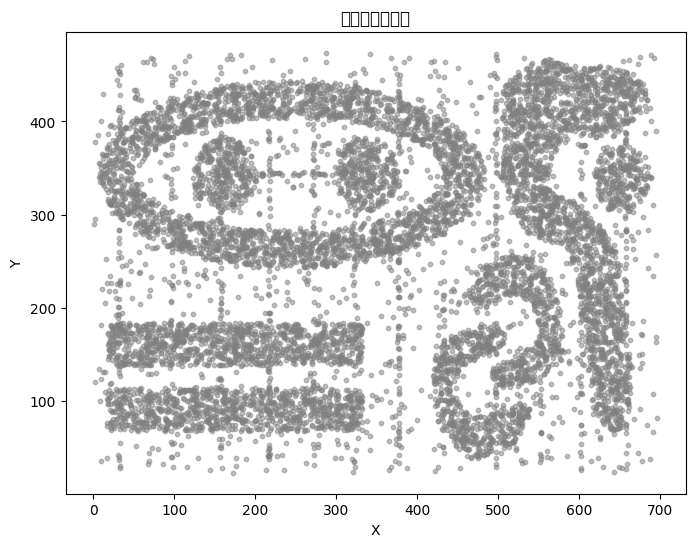

In [8]:
# 加载二维点数据
dots_file = './xjtu-ml-class/exp/data/dots/clusterData1.10k.dat'
X_dots = load_dots_data(dots_file)

print(f"二维点数据形状: {X_dots.shape}")
print(f"数据范围: X[{X_dots[:,0].min():.2f}, {X_dots[:,0].max():.2f}], Y[{X_dots[:,1].min():.2f}, {X_dots[:,1].max():.2f}]")

# 可视化原始数据
plt.figure(figsize=(8, 6))
plt.scatter(X_dots[:, 0], X_dots[:, 1], s=10, alpha=0.5, c='gray')
plt.title('原始二维点数据')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

### 6.1 对比手工实现与 Sklearn 的 KMeans


算法                        运行时间(s)         内存(MB)       簇数       轮廓系数        
--------------------------------------------------------------------------------
My KMeans                 0.0448          1.4748       4        0.4166      
Sklearn KMeans            0.4288          1.2242       4        0.4169      


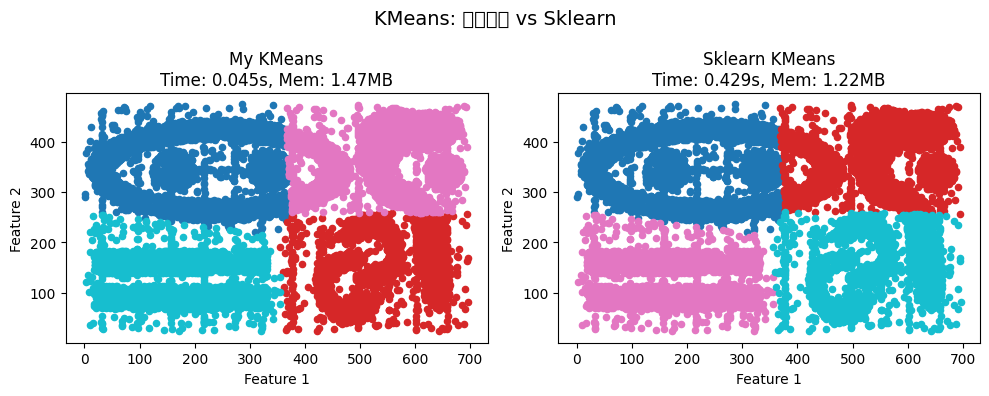

In [9]:
# 设置聚类数量（根据数据观察）
n_clusters_dots = 4

# 手工实现 KMeans
my_kmeans = MyKMeans(n_clusters=n_clusters_dots, random_state=42)
result_my_kmeans = measure_performance(my_kmeans, X_dots, name="My KMeans")

# Sklearn KMeans
sklearn_kmeans = SklearnKMeans(n_clusters=n_clusters_dots, random_state=42, n_init=10)
result_sklearn_kmeans = measure_performance(sklearn_kmeans, X_dots, name="Sklearn KMeans")

# 打印对比结果
print_comparison([result_my_kmeans, result_sklearn_kmeans])

# 可视化对比
plot_clustering_comparison(X_dots, [result_my_kmeans, result_sklearn_kmeans],
                          title="KMeans: 手工实现 vs Sklearn")

### 6.2 对比手工实现与 Sklearn 的层次聚类


算法                        运行时间(s)         内存(MB)       簇数       轮廓系数        
--------------------------------------------------------------------------------
My SLINK                  26.3173         0.1919       4        -0.3297     
Sklearn Single Linkage    0.2549          4.5869       4        -0.3297     


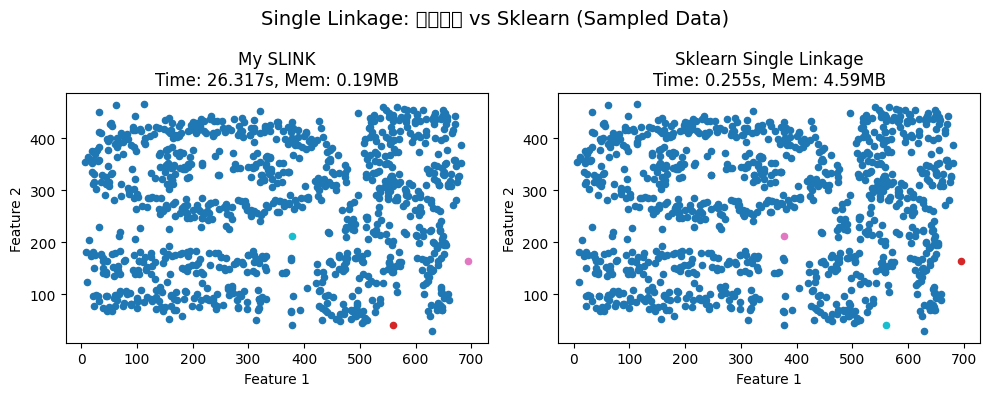

In [10]:
# 注意：SLINK 算法 O(n^2) 复杂度，对大数据集较慢，这里采样部分数据
np.random.seed(42)
sample_idx = np.random.choice(len(X_dots), 1000, replace=False)
X_dots_sample = X_dots[sample_idx]

# 手工实现 SLINK
my_slink = MySLINK(n_clusters=n_clusters_dots)
result_my_slink = measure_performance(my_slink, X_dots_sample, name="My SLINK")

# Sklearn 层次聚类（使用单链接）
sklearn_agg = AgglomerativeClustering(n_clusters=n_clusters_dots, linkage='single')
result_sklearn_agg = measure_performance(sklearn_agg, X_dots_sample, name="Sklearn Single Linkage")

# 打印对比结果
print_comparison([result_my_slink, result_sklearn_agg])

# 可视化对比
plot_clustering_comparison(X_dots_sample, [result_my_slink, result_sklearn_agg],
                          title="Single Linkage: 手工实现 vs Sklearn (Sampled Data)")

### 6.3 三种聚类算法对比（完整数据）


算法                        运行时间(s)         内存(MB)       簇数       轮廓系数        
--------------------------------------------------------------------------------
KMeans                    0.1288          1.0838       4        0.4169      
DBSCAN                    0.4219          2.5028       1        N/A         
Agglomerative (Ward)      6.0190          429.1209     4        0.3881      


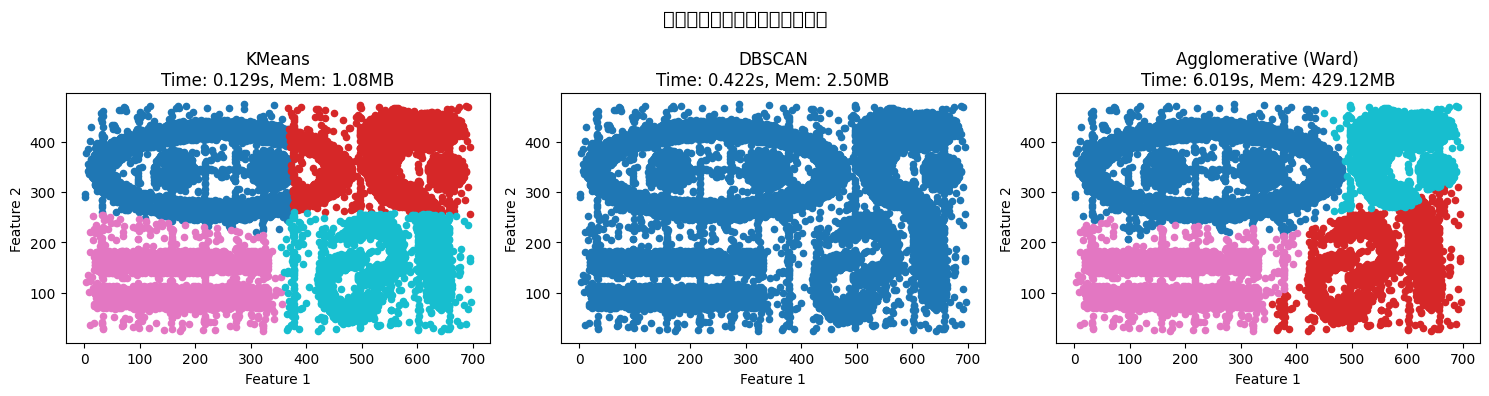

In [11]:
# KMeans
kmeans_model = SklearnKMeans(n_clusters=4, random_state=42, n_init=10)
result_kmeans = measure_performance(kmeans_model, X_dots, name="KMeans")

# DBSCAN
dbscan_model = DBSCAN(eps=50, min_samples=10)
result_dbscan = measure_performance(dbscan_model, X_dots, name="DBSCAN")

# 层次聚类（Ward，比单链接快）
agg_model = AgglomerativeClustering(n_clusters=4, linkage='ward')
result_agg = measure_performance(agg_model, X_dots, name="Agglomerative (Ward)")

# 打印对比
print_comparison([result_kmeans, result_dbscan, result_agg])

# 可视化
plot_clustering_comparison(X_dots, [result_kmeans, result_dbscan, result_agg],
                          title="二维点数据：三种聚类算法对比")

### 6.4 参数敏感性分析

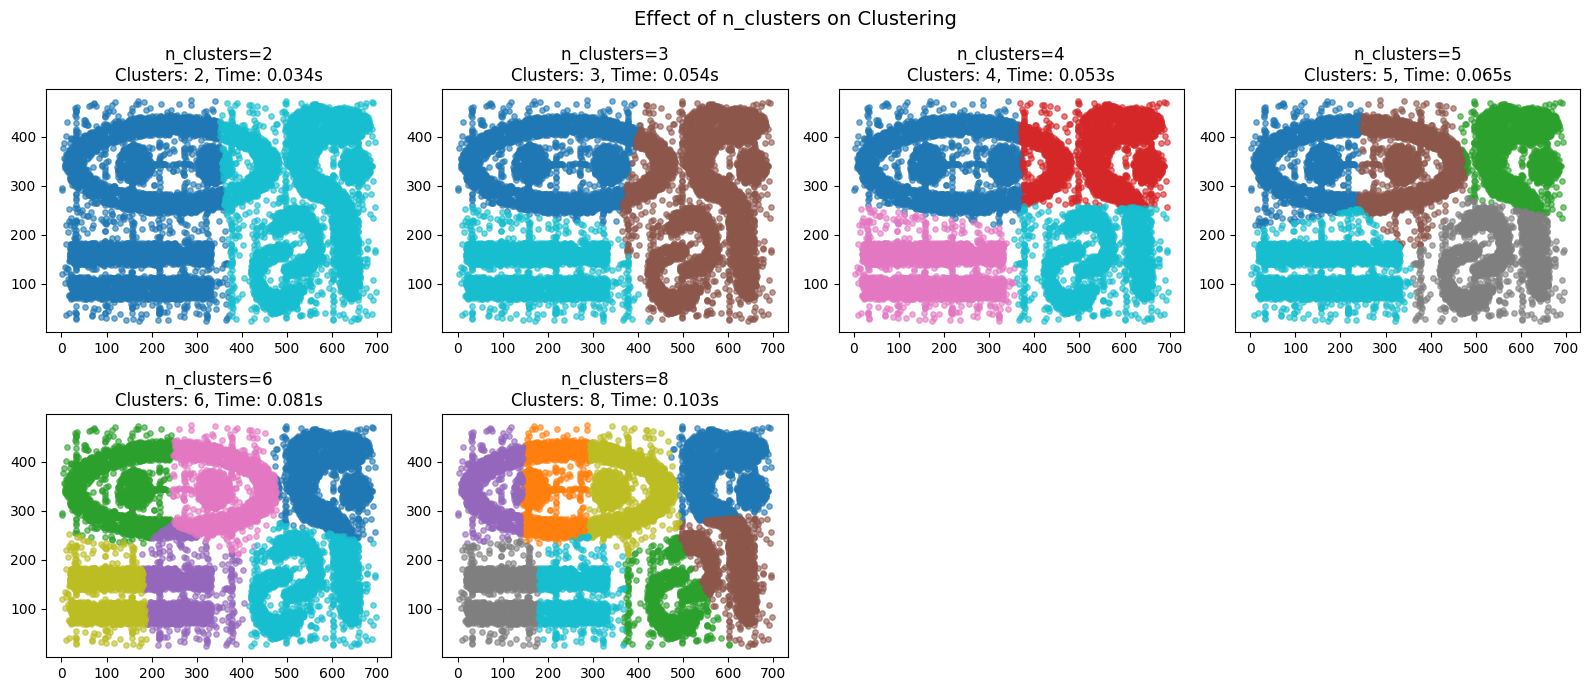

In [12]:
# KMeans: 簇数目影响
def kmeans_with_k(X, param_name, param_val, fixed_params):
    start = time.time()
    model = SklearnKMeans(n_clusters=param_val, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    runtime = time.time() - start
    return labels, runtime

plot_parameter_effect(X_dots, kmeans_with_k, 'n_clusters', [2, 3, 4, 5, 6, 8])

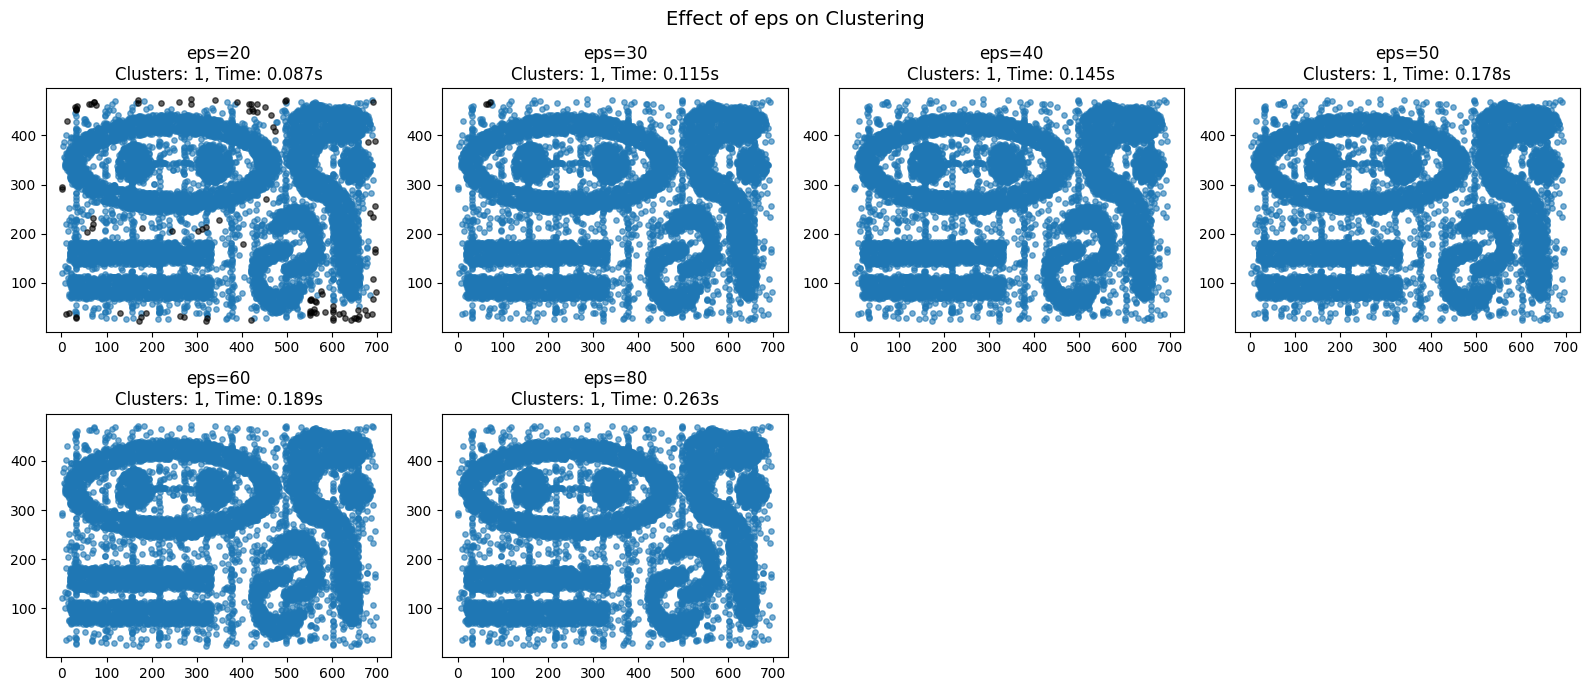

In [13]:
# DBSCAN: eps 参数影响
def dbscan_with_eps(X, param_name, param_val, fixed_params):
    start = time.time()
    model = DBSCAN(eps=param_val, min_samples=10)
    labels = model.fit_predict(X)
    runtime = time.time() - start
    return labels, runtime

plot_parameter_effect(X_dots, dbscan_with_eps, 'eps', [20, 30, 40, 50, 60, 80])

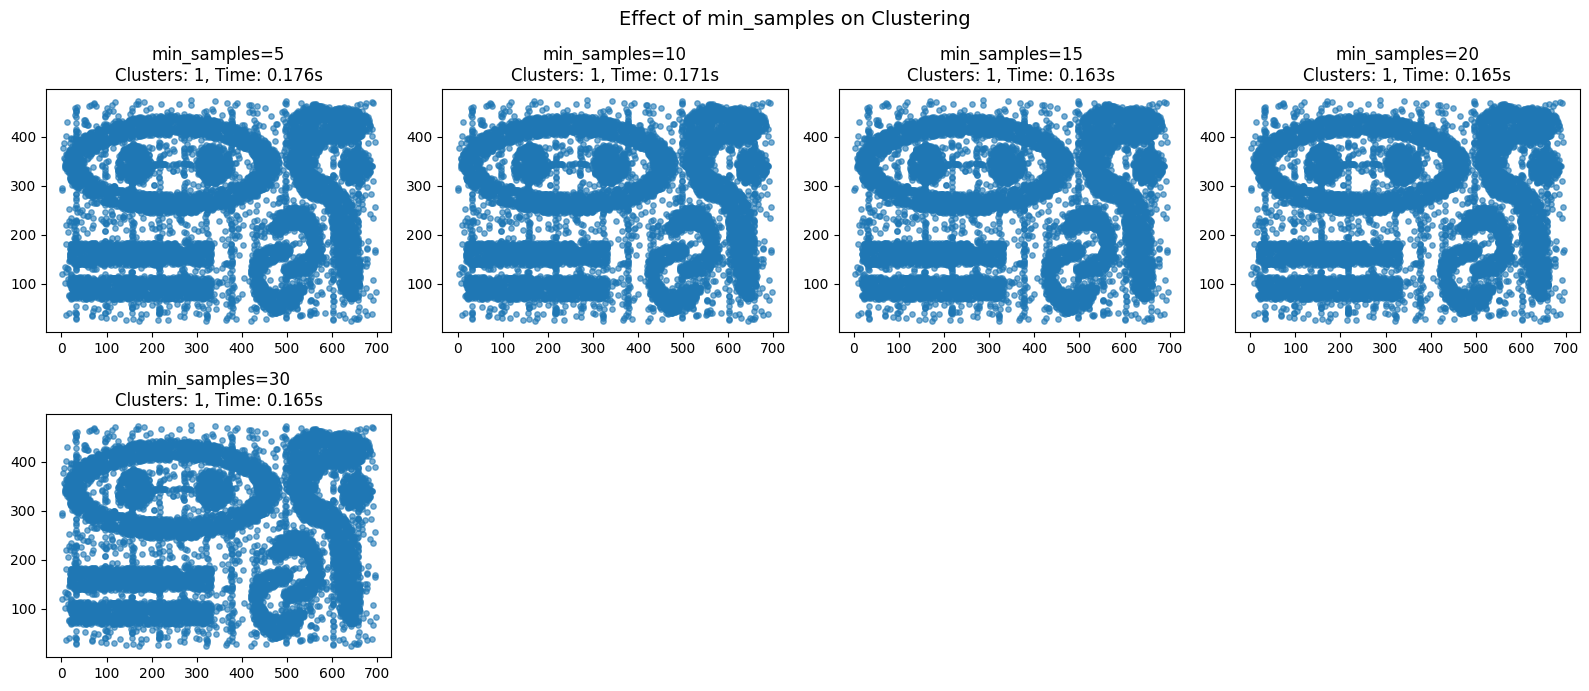

In [14]:
# DBSCAN: min_samples 参数影响
def dbscan_with_min_samples(X, param_name, param_val, fixed_params):
    start = time.time()
    model = DBSCAN(eps=50, min_samples=param_val)
    labels = model.fit_predict(X)
    runtime = time.time() - start
    return labels, runtime

plot_parameter_effect(X_dots, dbscan_with_min_samples, 'min_samples', [5, 10, 15, 20, 30])

---

# 实验二：UCI Iris 数据集聚类

In [15]:
# 加载 Iris 数据
X_iris, y_iris, iris_classes = load_iris_data('./xjtu-ml-class/exp/data/iris/iris.data')

print(f"Iris 数据形状: {X_iris.shape}")
print(f"类别数: {len(iris_classes)} - {iris_classes}")
print(f"各类样本数: {np.bincount(y_iris)}")

# 标准化数据
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

Iris 数据形状: (150, 4)
类别数: 3 - ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
各类样本数: [50 50 50]


### 7.1 手工实现 vs Sklearn（KMeans 和 SLINK）


算法                        运行时间(s)         内存(MB)       簇数       轮廓系数        
--------------------------------------------------------------------------------
My KMeans                 0.0080          0.0513       3        0.4621      
Sklearn KMeans            0.0355          0.0328       3        0.4590      
My SLINK                  0.4579          0.0235       3        0.5029      
Sklearn Single Linkage    0.0039          0.0203       3        0.5029      

外部指标（需要真实标签）:
算法                        ARI             NMI            
------------------------------------------------------------
My KMeans                 0.5923          0.6427         
Sklearn KMeans            0.6201          0.6595         
My SLINK                  0.5584          0.7201         
Sklearn Single Linkage    0.5584          0.7201         


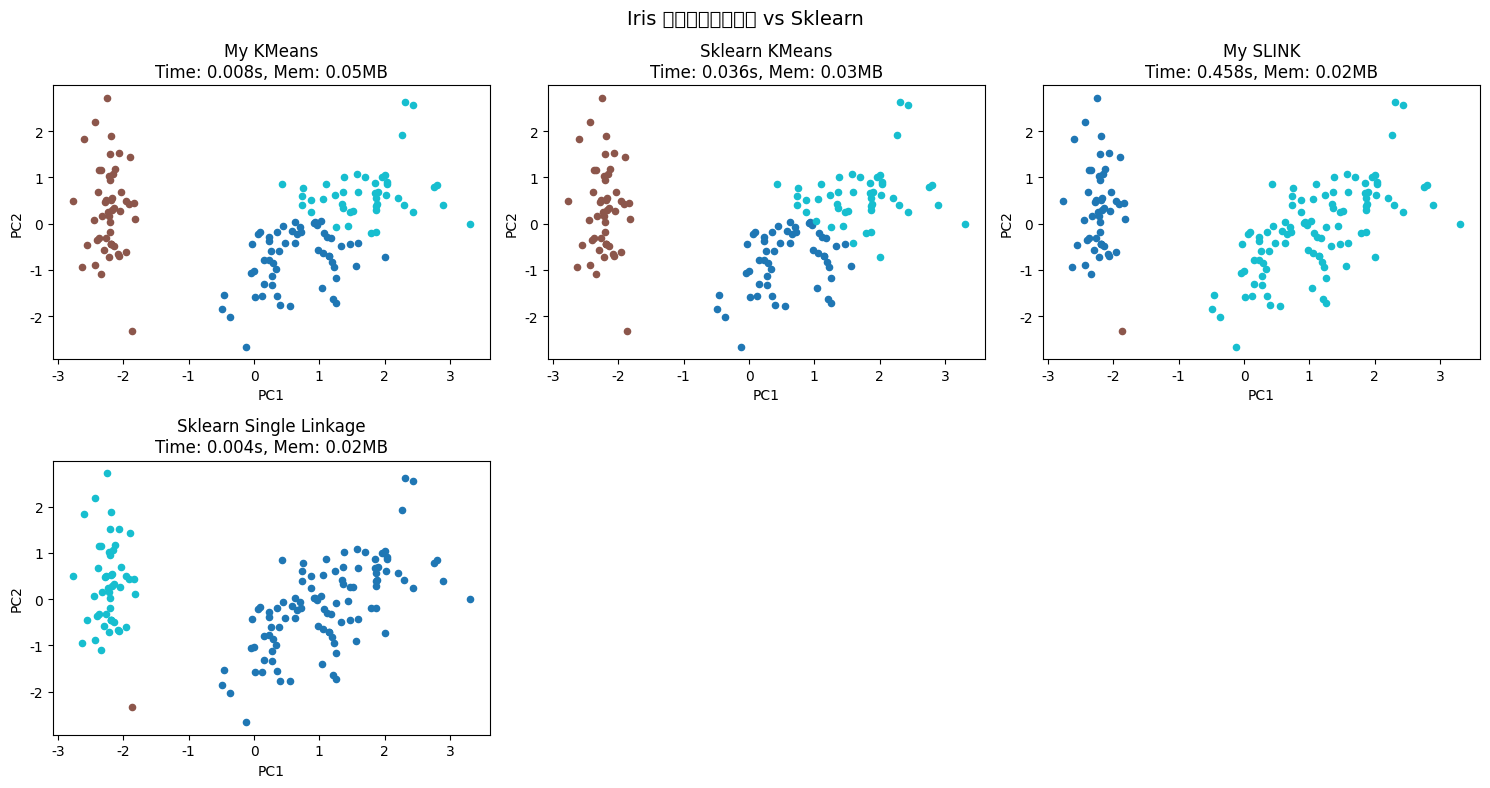

In [16]:
n_clusters_iris = 3

# 手工 KMeans
my_kmeans_iris = MyKMeans(n_clusters=n_clusters_iris, random_state=42)
result_my_kmeans_iris = measure_performance(my_kmeans_iris, X_iris_scaled,
                                             true_labels=y_iris, name="My KMeans")

# Sklearn KMeans
sklearn_kmeans_iris = SklearnKMeans(n_clusters=n_clusters_iris, random_state=42, n_init=10)
result_sklearn_kmeans_iris = measure_performance(sklearn_kmeans_iris, X_iris_scaled,
                                                  true_labels=y_iris, name="Sklearn KMeans")

# 手工 SLINK
my_slink_iris = MySLINK(n_clusters=n_clusters_iris)
result_my_slink_iris = measure_performance(my_slink_iris, X_iris_scaled,
                                            true_labels=y_iris, name="My SLINK")

# Sklearn 层次聚类
sklearn_agg_iris = AgglomerativeClustering(n_clusters=n_clusters_iris, linkage='single')
result_sklearn_agg_iris = measure_performance(sklearn_agg_iris, X_iris_scaled,
                                              true_labels=y_iris, name="Sklearn Single Linkage")

# 打印对比
print_comparison([result_my_kmeans_iris, result_sklearn_kmeans_iris,
                result_my_slink_iris, result_sklearn_agg_iris])

# 可视化（使用 PCA 降维）
plot_clustering_comparison(X_iris_scaled,
                        [result_my_kmeans_iris, result_sklearn_kmeans_iris,
                         result_my_slink_iris, result_sklearn_agg_iris],
                        title="Iris 数据集：手工实现 vs Sklearn", use_pca=True)

### 7.2 三种算法对比


算法                        运行时间(s)         内存(MB)       簇数       轮廓系数        
--------------------------------------------------------------------------------
KMeans                    0.0397          0.0345       3        0.4590      
DBSCAN                    0.0073          0.0535       2        0.5963      
Agglomerative (Average)   0.0045          0.1059       3        0.4795      

外部指标（需要真实标签）:
算法                        ARI             NMI            
------------------------------------------------------------
KMeans                    0.6201          0.6595         
DBSCAN                    0.5709          0.7350         
Agglomerative (Average)   0.5621          0.7131         


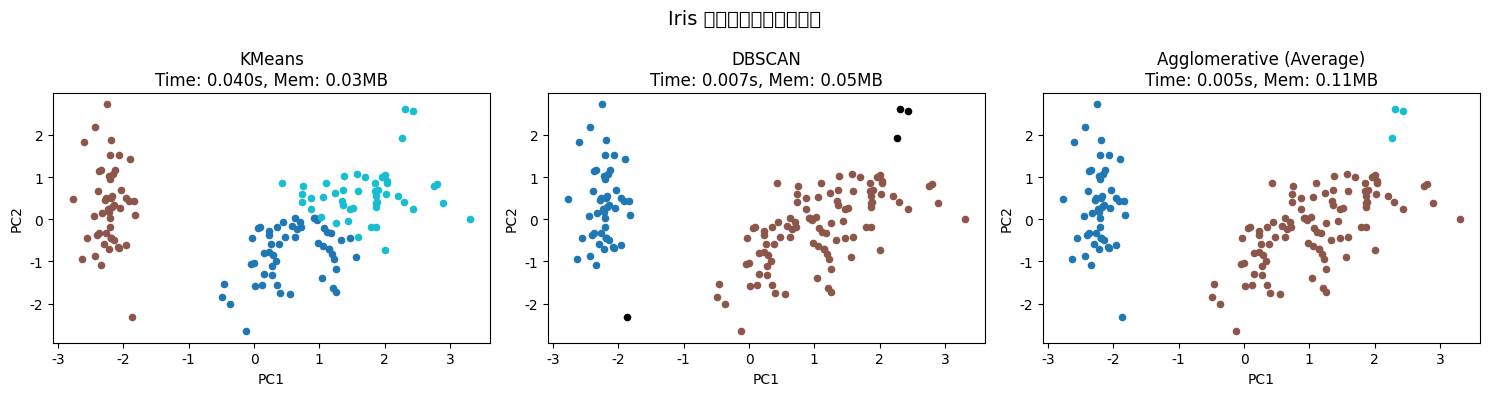

In [17]:
# KMeans
kmeans_iris = SklearnKMeans(n_clusters=3, random_state=42, n_init=10)
result_kmeans_iris = measure_performance(kmeans_iris, X_iris_scaled,
                                        true_labels=y_iris, name="KMeans")

# DBSCAN
dbscan_iris = DBSCAN(eps=0.8, min_samples=5)
result_dbscan_iris = measure_performance(dbscan_iris, X_iris_scaled,
                                          true_labels=y_iris, name="DBSCAN")

# 层次聚类（平均链接）
agg_iris = AgglomerativeClustering(n_clusters=3, linkage='average')
result_agg_iris = measure_performance(agg_iris, X_iris_scaled,
                                     true_labels=y_iris, name="Agglomerative (Average)")

print_comparison([result_kmeans_iris, result_dbscan_iris, result_agg_iris])

plot_clustering_comparison(X_iris_scaled,
                          [result_kmeans_iris, result_dbscan_iris, result_agg_iris],
                          title="Iris 数据集：三种聚类算法", use_pca=True)

### 7.3 Iris 数据集参数敏感性分析

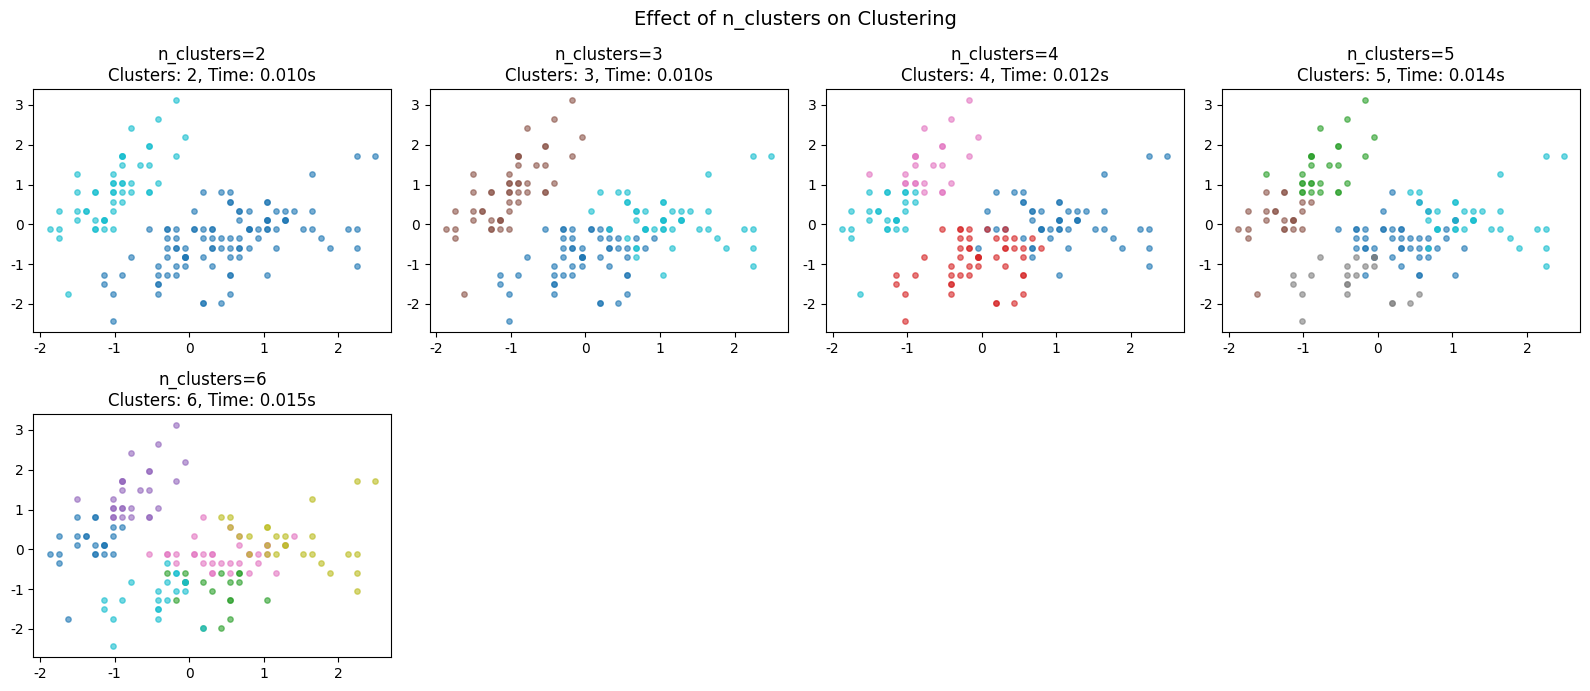

In [18]:
# KMeans 簇数目影响
def kmeans_iris_k(X, param_name, param_val, fixed_params):
    start = time.time()
    model = SklearnKMeans(n_clusters=param_val, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    runtime = time.time() - start
    return labels, runtime

plot_parameter_effect(X_iris_scaled, kmeans_iris_k, 'n_clusters', [2, 3, 4, 5, 6])

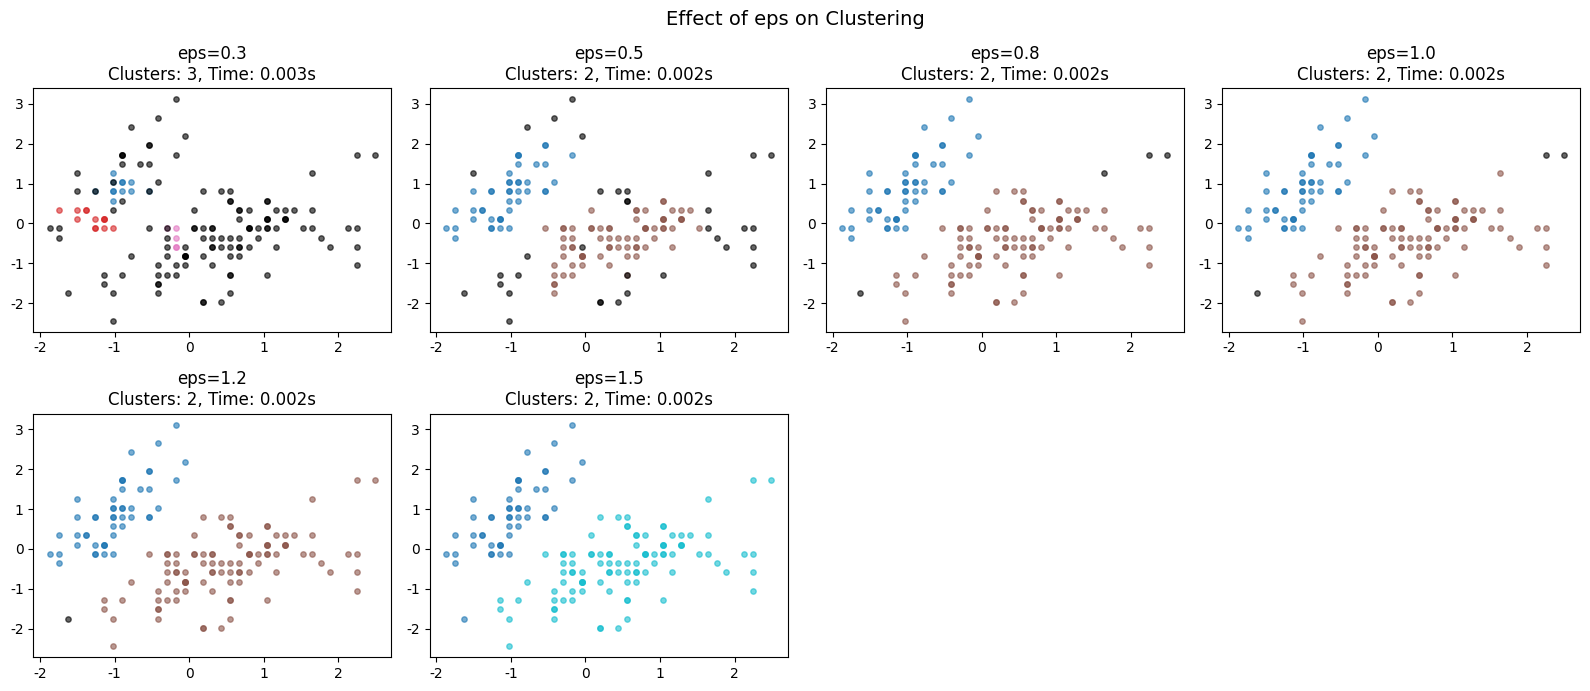

In [19]:
# DBSCAN eps 影响
def dbscan_iris_eps(X, param_name, param_val, fixed_params):
    start = time.time()
    model = DBSCAN(eps=param_val, min_samples=5)
    labels = model.fit_predict(X)
    runtime = time.time() - start
    return labels, runtime

plot_parameter_effect(X_iris_scaled, dbscan_iris_eps, 'eps', [0.3, 0.5, 0.8, 1.0, 1.2, 1.5])

---

# 实验三：时序数据聚类

时序数据形状: (105, 144)
时序长度: 144
类别数: 7
各类样本数: [ 0 15 14  9 16 13 18 20]


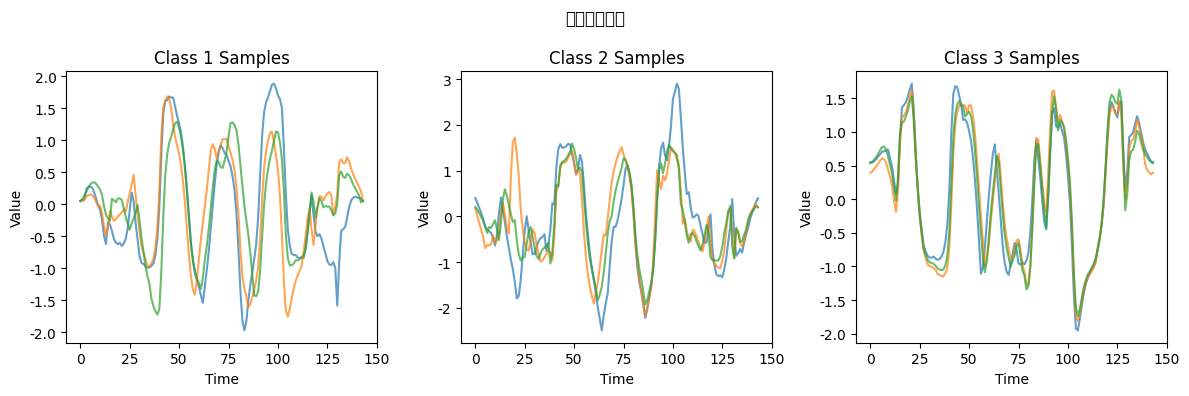

In [20]:
# 加载时序数据
X_ts, y_ts = load_timeseries_data('./xjtu-ml-class/exp/data/timeSeries/Plane_TRAIN.txt')

print(f"时序数据形状: {X_ts.shape}")
print(f"时序长度: {X_ts.shape[1]}")
print(f"类别数: {len(set(y_ts))}")
print(f"各类样本数: {np.bincount(y_ts)}")

# 标准化
scaler_ts = StandardScaler()
X_ts_scaled = scaler_ts.fit_transform(X_ts)

# 可视化部分时序样本
plt.figure(figsize=(12, 4))
for i, label in enumerate(sorted(set(y_ts))[:3]):
    plt.subplot(1, 3, i+1)
    samples = X_ts_scaled[y_ts == label][:3]
    for s in samples:
        plt.plot(s, alpha=0.7)
    plt.title(f'Class {label} Samples')
    plt.xlabel('Time')
    plt.ylabel('Value')
plt.suptitle('时序数据样本')
plt.tight_layout()
plt.show()

### 8.1 时序数据聚类对比


算法                        运行时间(s)         内存(MB)       簇数       轮廓系数        
--------------------------------------------------------------------------------
My KMeans                 0.0160          0.9679       7        0.4319      
Sklearn KMeans            0.0903          0.2975       7        0.4917      

外部指标（需要真实标签）:
算法                        ARI             NMI            
------------------------------------------------------------
My KMeans                 0.7853          0.8683         
Sklearn KMeans            0.8273          0.9095         


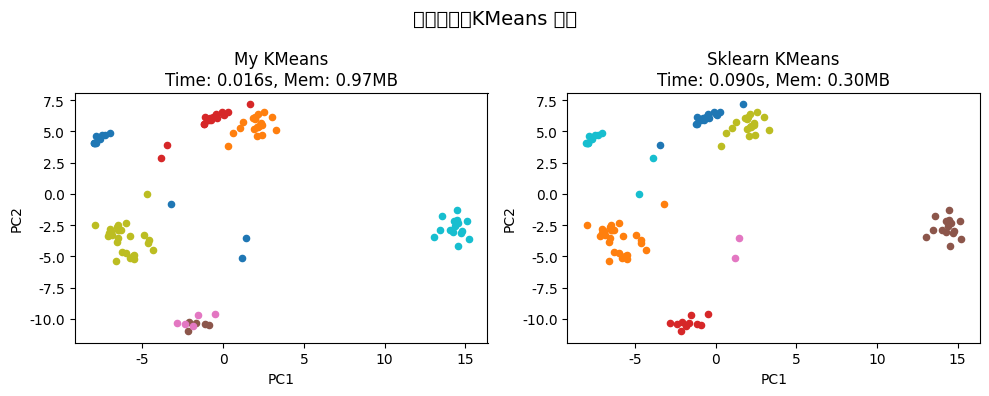

In [21]:
n_clusters_ts = len(set(y_ts))

# 手工 KMeans
my_kmeans_ts = MyKMeans(n_clusters=n_clusters_ts, random_state=42)
result_my_kmeans_ts = measure_performance(my_kmeans_ts, X_ts_scaled,
                                           true_labels=y_ts, name="My KMeans")

# Sklearn KMeans
sklearn_kmeans_ts = SklearnKMeans(n_clusters=n_clusters_ts, random_state=42, n_init=10)
result_sklearn_kmeans_ts = measure_performance(sklearn_kmeans_ts, X_ts_scaled,
                                              true_labels=y_ts, name="Sklearn KMeans")

# 打印对比
print_comparison([result_my_kmeans_ts, result_sklearn_kmeans_ts])

# 使用 PCA 可视化
plot_clustering_comparison(X_ts_scaled,
                          [result_my_kmeans_ts, result_sklearn_kmeans_ts],
                          title="时序数据：KMeans 对比", use_pca=True)


算法                        运行时间(s)         内存(MB)       簇数       轮廓系数        
--------------------------------------------------------------------------------
KMeans                    0.0600          0.2986       7        0.4917      
DBSCAN                    0.0162          0.2485       5        0.5117      
Agglomerative (Ward)      0.0067          0.0652       7        0.4887      

外部指标（需要真实标签）:
算法                        ARI             NMI            
------------------------------------------------------------
KMeans                    0.8273          0.9095         
DBSCAN                    0.6655          0.8678         
Agglomerative (Ward)      0.8413          0.9340         


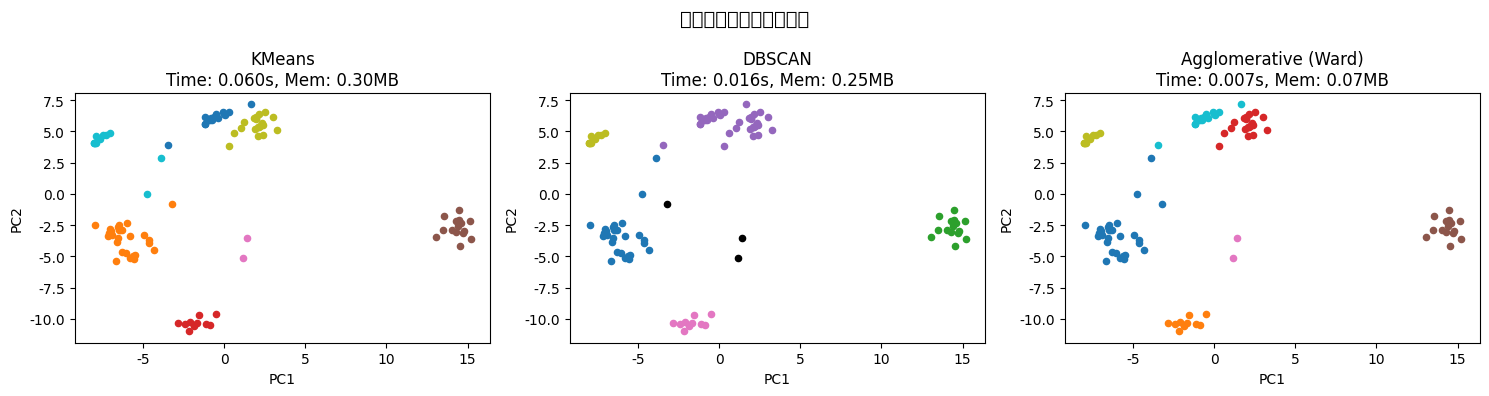

In [22]:
# 三种算法对比
kmeans_ts = SklearnKMeans(n_clusters=n_clusters_ts, random_state=42, n_init=10)
result_kmeans_ts = measure_performance(kmeans_ts, X_ts_scaled,
                                      true_labels=y_ts, name="KMeans")

dbscan_ts = DBSCAN(eps=8, min_samples=3)
result_dbscan_ts = measure_performance(dbscan_ts, X_ts_scaled,
                                      true_labels=y_ts, name="DBSCAN")

agg_ts = AgglomerativeClustering(n_clusters=n_clusters_ts, linkage='ward')
result_agg_ts = measure_performance(agg_ts, X_ts_scaled,
                                   true_labels=y_ts, name="Agglomerative (Ward)")

print_comparison([result_kmeans_ts, result_dbscan_ts, result_agg_ts])

plot_clustering_comparison(X_ts_scaled,
                          [result_kmeans_ts, result_dbscan_ts, result_agg_ts],
                          title="时序数据：三种聚类算法", use_pca=True)

---

# 实验四：Wine Quality 数据集聚类

In [23]:
# 加载红酒质量数据
X_wine, y_wine = load_wine_data('./xjtu-ml-class/exp/data/wine+quality/winequality-red.csv')

print(f"Wine Quality 数据形状: {X_wine.shape}")
print(f"特征数: {X_wine.shape[1]}")
print(f"质量等级: {sorted(set(y_wine))}")
print(f"各类样本数: {np.bincount(y_wine - y_wine.min())}")

# 标准化
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

Wine Quality 数据形状: (1599, 11)
特征数: 11
质量等级: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
各类样本数: [ 10  53 681 638 199  18]



算法                        运行时间(s)         内存(MB)       簇数       轮廓系数        
--------------------------------------------------------------------------------
My KMeans                 0.0282          1.0538       6        0.1718      
Sklearn KMeans            0.1594          0.3332       6        0.1947      

外部指标（需要真实标签）:
算法                        ARI             NMI            
------------------------------------------------------------
My KMeans                 0.0675          0.0997         
Sklearn KMeans            0.0619          0.0925         


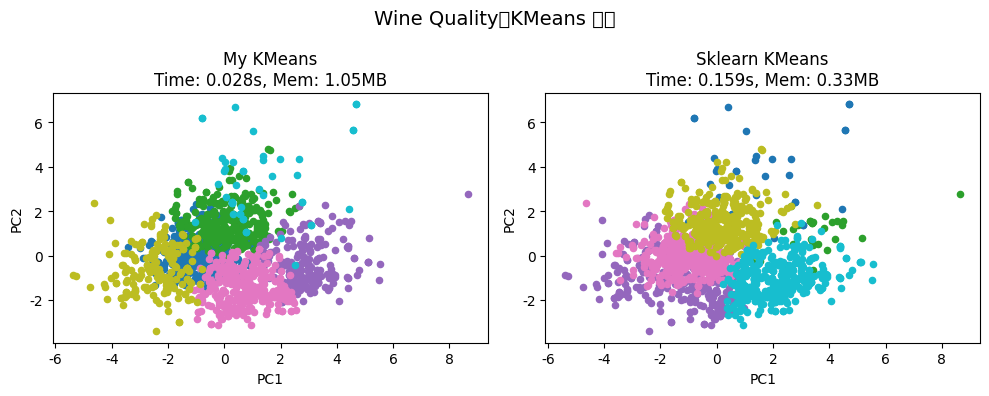

In [24]:
# 手工实现 vs Sklearn
n_clusters_wine = 6  # 质量等级 3-8

my_kmeans_wine = MyKMeans(n_clusters=n_clusters_wine, random_state=42)
result_my_kmeans_wine = measure_performance(my_kmeans_wine, X_wine_scaled,
                                             true_labels=y_wine, name="My KMeans")

sklearn_kmeans_wine = SklearnKMeans(n_clusters=n_clusters_wine, random_state=42, n_init=10)
result_sklearn_kmeans_wine = measure_performance(sklearn_kmeans_wine, X_wine_scaled,
                                                  true_labels=y_wine, name="Sklearn KMeans")

print_comparison([result_my_kmeans_wine, result_sklearn_kmeans_wine])

plot_clustering_comparison(X_wine_scaled,
                          [result_my_kmeans_wine, result_sklearn_kmeans_wine],
                          title="Wine Quality：KMeans 对比", use_pca=True)


算法                        运行时间(s)         内存(MB)       簇数       轮廓系数        
--------------------------------------------------------------------------------
KMeans                    0.1366          0.3343       6        0.1947      
DBSCAN                    0.1353          0.7348       2        0.5444      
Agglomerative (Ward)      0.1992          10.9692      6        0.1495      

外部指标（需要真实标签）:
算法                        ARI             NMI            
------------------------------------------------------------
KMeans                    0.0619          0.0925         
DBSCAN                    -0.0036         0.0047         
Agglomerative (Ward)      0.0610          0.0779         


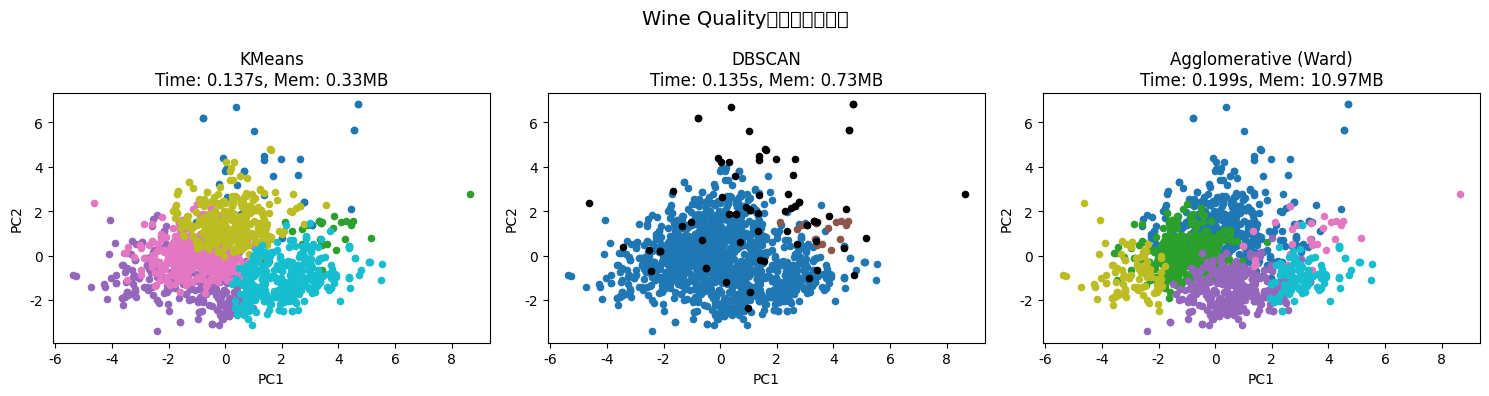

In [25]:
# 三种算法对比
kmeans_wine = SklearnKMeans(n_clusters=n_clusters_wine, random_state=42, n_init=10)
result_kmeans_wine = measure_performance(kmeans_wine, X_wine_scaled,
                                        true_labels=y_wine, name="KMeans")

dbscan_wine = DBSCAN(eps=2.5, min_samples=10)
result_dbscan_wine = measure_performance(dbscan_wine, X_wine_scaled,
                                        true_labels=y_wine, name="DBSCAN")

agg_wine = AgglomerativeClustering(n_clusters=n_clusters_wine, linkage='ward')
result_agg_wine = measure_performance(agg_wine, X_wine_scaled,
                                     true_labels=y_wine, name="Agglomerative (Ward)")

print_comparison([result_kmeans_wine, result_dbscan_wine, result_agg_wine])

plot_clustering_comparison(X_wine_scaled,
                          [result_kmeans_wine, result_dbscan_wine, result_agg_wine],
                          title="Wine Quality：三种聚类算法", use_pca=True)

---

# 综合对比总结

In [26]:
# 汇总所有结果
all_results = {
    '二维点数据': [result_kmeans, result_dbscan, result_agg],
    'Iris': [result_kmeans_iris, result_dbscan_iris, result_agg_iris],
    '时序数据': [result_kmeans_ts, result_dbscan_ts, result_agg_ts],
    'Wine Quality': [result_kmeans_wine, result_dbscan_wine, result_agg_wine]
}

# 创建汇总表格
summary_data = []
for dataset_name, results in all_results.items():
    for r in results:
        row = {
            '数据集': dataset_name,
            '算法': r['name'],
            '运行时间(s)': f"{r['runtime']:.4f}",
            '内存(MB)': f"{r['memory_mb']:.4f}",
            '簇数': r['n_clusters'],
        }
        if 'silhouette' in r and r['silhouette'] is not None:
            row['轮廓系数'] = f"{r['silhouette']:.4f}"
        if 'ARI' in r:
            row['ARI'] = f"{r['ARI']:.4f}"
            row['NMI'] = f"{r['NMI']:.4f}"
        summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print("\n综合对比汇总:")
print(summary_df.to_string(index=False))


综合对比汇总:
         数据集                      算法 运行时间(s)   内存(MB)  簇数   轮廓系数     ARI    NMI
       二维点数据                  KMeans  0.1288   1.0838   4 0.4169     NaN    NaN
       二维点数据                  DBSCAN  0.4219   2.5028   1    NaN     NaN    NaN
       二维点数据    Agglomerative (Ward)  6.0190 429.1209   4 0.3881     NaN    NaN
        Iris                  KMeans  0.0397   0.0345   3 0.4590  0.6201 0.6595
        Iris                  DBSCAN  0.0073   0.0535   2 0.5963  0.5709 0.7350
        Iris Agglomerative (Average)  0.0045   0.1059   3 0.4795  0.5621 0.7131
        时序数据                  KMeans  0.0600   0.2986   7 0.4917  0.8273 0.9095
        时序数据                  DBSCAN  0.0162   0.2485   5 0.5117  0.6655 0.8678
        时序数据    Agglomerative (Ward)  0.0067   0.0652   7 0.4887  0.8413 0.9340
Wine Quality                  KMeans  0.1366   0.3343   6 0.1947  0.0619 0.0925
Wine Quality                  DBSCAN  0.1353   0.7348   2 0.5444 -0.0036 0.0047
Wine Quality    Agglomerative (

## 实验结论

### 1. 手工实现 vs Sklearn
- **KMeans**: 手工实现与 Sklearn 结果基本一致，Sklearn 经过优化速度更快
- **SLINK**: 手工实现正确实现了 SLINK 算法的核心逻辑，但 Sklearn 使用更高效的数据结构
- **性能**: Sklearn 的 Cython 优化使运行时间显著优于纯 Python 实现

### 2. 三种聚类算法特点
- **KMeans**: 适合球形簇，需要预设簇数，对初始值敏感，速度最快
- **DBSCAN**: 能发现任意形状簇，自动识别噪声，不需要预设簇数，但对参数敏感
- **层次聚类**: 生成树状结构，可得到不同粒度聚类，但计算复杂度较高

### 3. 参数影响
- **KMeans (n_clusters)**: 簇数过少会合并不同簇，过多会分裂自然簇
- **DBSCAN (eps)**: 过小导致大量噪声，过大导致簇合并
- **DBSCAN (min_samples)**: 影响核心点判定，进而影响簇的密度要求

### 4. 不同数据类型适用性
- **二维点数据**: 三种算法均可，DBSCAN 对噪声鲁棒
- **表格数据(Iris/Wine)**: KMeans 和层次聚类表现较好
- **时序数据**: 需要先降维或提取特征，欧氏距离可能不是最佳度量